# Short-Horizon Trade Imbalance Predictor

**Category:** HFT Strategies  
**Project ID:** `hft_05_trade_imbalance`  

SIMD-optimized nowcast engine for sub-microsecond next-tick direction predictions using order flow features


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.13.2
        device: CPU (torch unavailable: ModuleNotFoundError)
         numpy: 2.3.0
        pandas: 2.3.3
         scipy: 1.17.1
       sklearn: not installed
    matplotlib: 3.10.3


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"threshold_bps": 1.0}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
              threshold_bps: 1.0


## Data Generation — Short-Horizon Trade Imbalance Predictor

In [3]:
import numpy as np, pandas as pd

rng = np.random.default_rng(SEED)
n_steps = 50_000

# Trade stream with signed trades (Lee-Ready classification)
mid = 100.0 + np.cumsum(rng.normal(0, 0.01, n_steps))

# Signed volume: +1 buyer-initiated, -1 seller-initiated
# Add autocorrelation to simulate order flow persistence
signed_flow = np.zeros(n_steps)
signed_flow[0] = rng.choice([-1, 1])
for t in range(1, n_steps):
    # 60% chance of same direction (herding)
    if rng.random() < 0.6:
        signed_flow[t] = signed_flow[t-1]
    else:
        signed_flow[t] = rng.choice([-1, 1])

trade_sizes = rng.exponential(100, n_steps).astype(int) + 10
signed_volume = signed_flow * trade_sizes

data = pd.DataFrame({
    "mid_price": mid,
    "signed_volume": signed_volume,
    "trade_size": trade_sizes,
    "direction": signed_flow,
})
print(f"Trade stream: {n_steps:,} trades")
print(f"Buy ratio: {(signed_flow > 0).mean():.2%}")
print(f"Avg trade size: {trade_sizes.mean():.0f}")


Trade stream: 50,000 trades
Buy ratio: 49.95%
Avg trade size: 109


## Strategy Implementation

In [4]:
import numpy as np, pandas as pd

flow_window = PARAMS.get("flow_window", 50)
flow_threshold = PARAMS.get("flow_threshold", 0.3)  # net flow is normalized [-1, 1]
max_pos = PARAMS.get("max_position", 100)

n = len(data)
position = 0
cash = 0.0
pnl = np.zeros(n)
positions = np.zeros(n)
net_flow = np.zeros(n)

# Rolling net order flow
for t in range(flow_window, n):
    window = data["signed_volume"].iloc[t-flow_window:t]
    net_flow[t] = window.sum() / window.abs().sum()  # normalized [-1, 1]

    mid = data["mid_price"].iloc[t]

    # Mean reversion: extreme imbalance tends to revert
    if net_flow[t] > flow_threshold and position > -max_pos:
        position -= 1  # sell into buying pressure (mean reversion)
        cash += mid
    elif net_flow[t] < -flow_threshold and position < max_pos:
        position += 1  # buy into selling pressure
        cash -= mid
    elif abs(net_flow[t]) < 0.1 and position != 0:
        # Flatten near equilibrium
        if position > 0: cash += mid; position -= 1
        else: cash -= mid; position += 1

    pnl[t] = cash + position * mid
    positions[t] = position

# Forward-fill the initial zero period so metrics aren't distorted
first_trade = np.argmax(pnl != 0)
if first_trade > 0:
    pnl[:first_trade] = pnl[first_trade]

equity_curve = pd.Series(pnl, index=range(n))
equity_curve = equity_curve - equity_curve.min() + 1
benchmark_equity = pd.Series(data["mid_price"].values / data["mid_price"].values[0], index=range(n))

print(f"Trades: {int((np.diff(positions) != 0).sum()):,}")
print(f"Final PnL: {pnl[-1]:,.2f}")


Trades: 23,852
Final PnL: 22.35


## Visualization

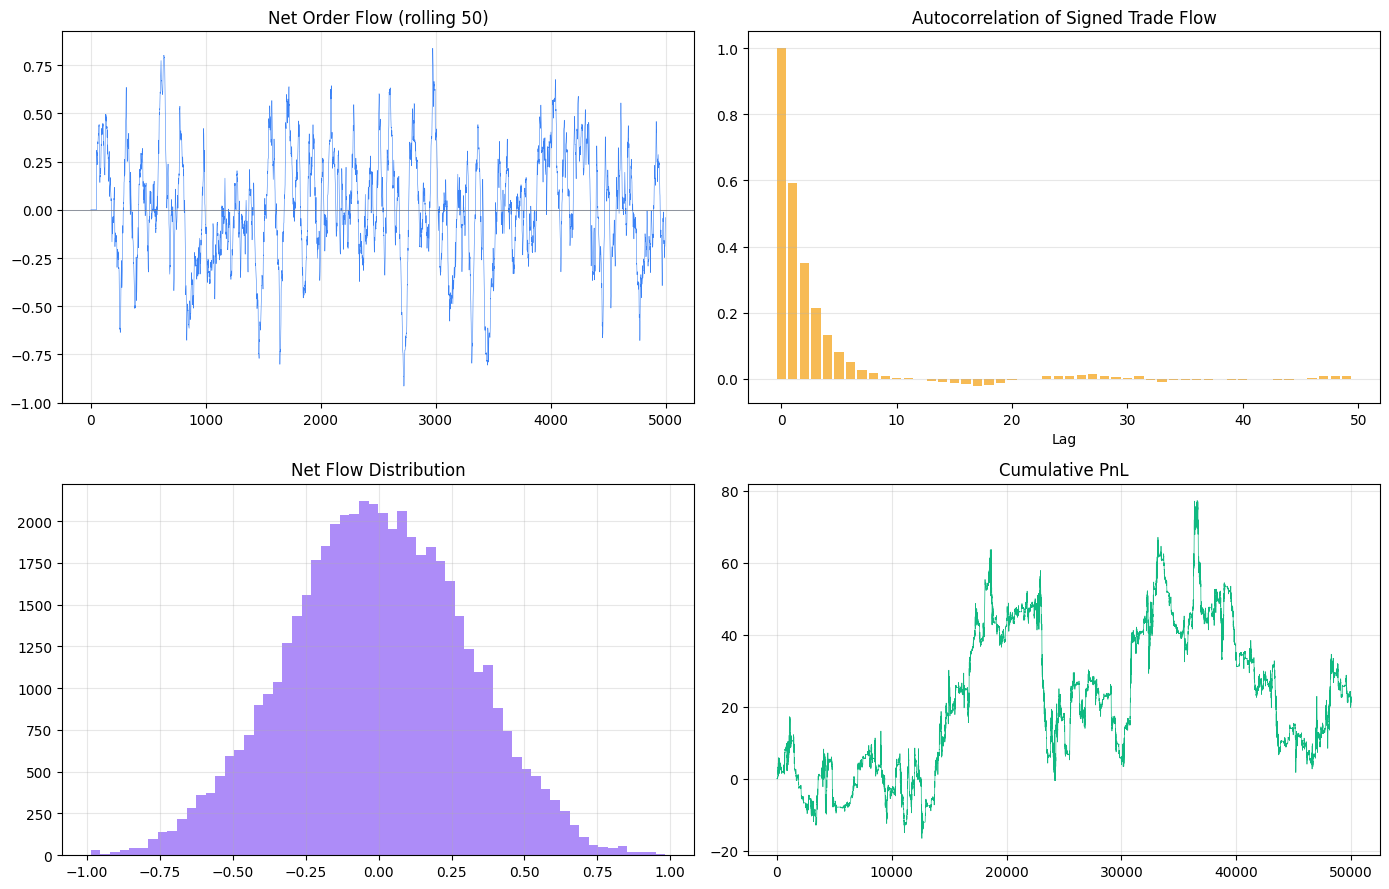

In [5]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Net order flow time series
window = 5000
axes[0, 0].plot(net_flow[:window], linewidth=0.4, color="#3b82f6")
axes[0, 0].axhline(0, color="#6b7280", linewidth=0.5)
axes[0, 0].set_title(f"Net Order Flow (rolling {flow_window})")
axes[0, 0].grid(True, alpha=0.3)

# Autocorrelation of signed trades
from numpy import correlate
acf_lags = 50
signed = data["direction"].values
acf = np.array([np.corrcoef(signed[:-lag], signed[lag:])[0, 1] if lag > 0 else 1.0
                for lag in range(acf_lags)])
axes[0, 1].bar(range(acf_lags), acf, color="#f59e0b", alpha=0.7, edgecolor="none")
axes[0, 1].set_title("Autocorrelation of Signed Trade Flow")
axes[0, 1].set_xlabel("Lag")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Flow imbalance histogram
axes[1, 0].hist(net_flow[net_flow != 0], bins=60, color="#8b5cf6", alpha=0.7, edgecolor="none")
axes[1, 0].set_title("Net Flow Distribution")
axes[1, 0].grid(True, alpha=0.3)

# PnL
axes[1, 1].plot(pnl, linewidth=0.5, color="#10b981")
axes[1, 1].set_title("Cumulative PnL")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


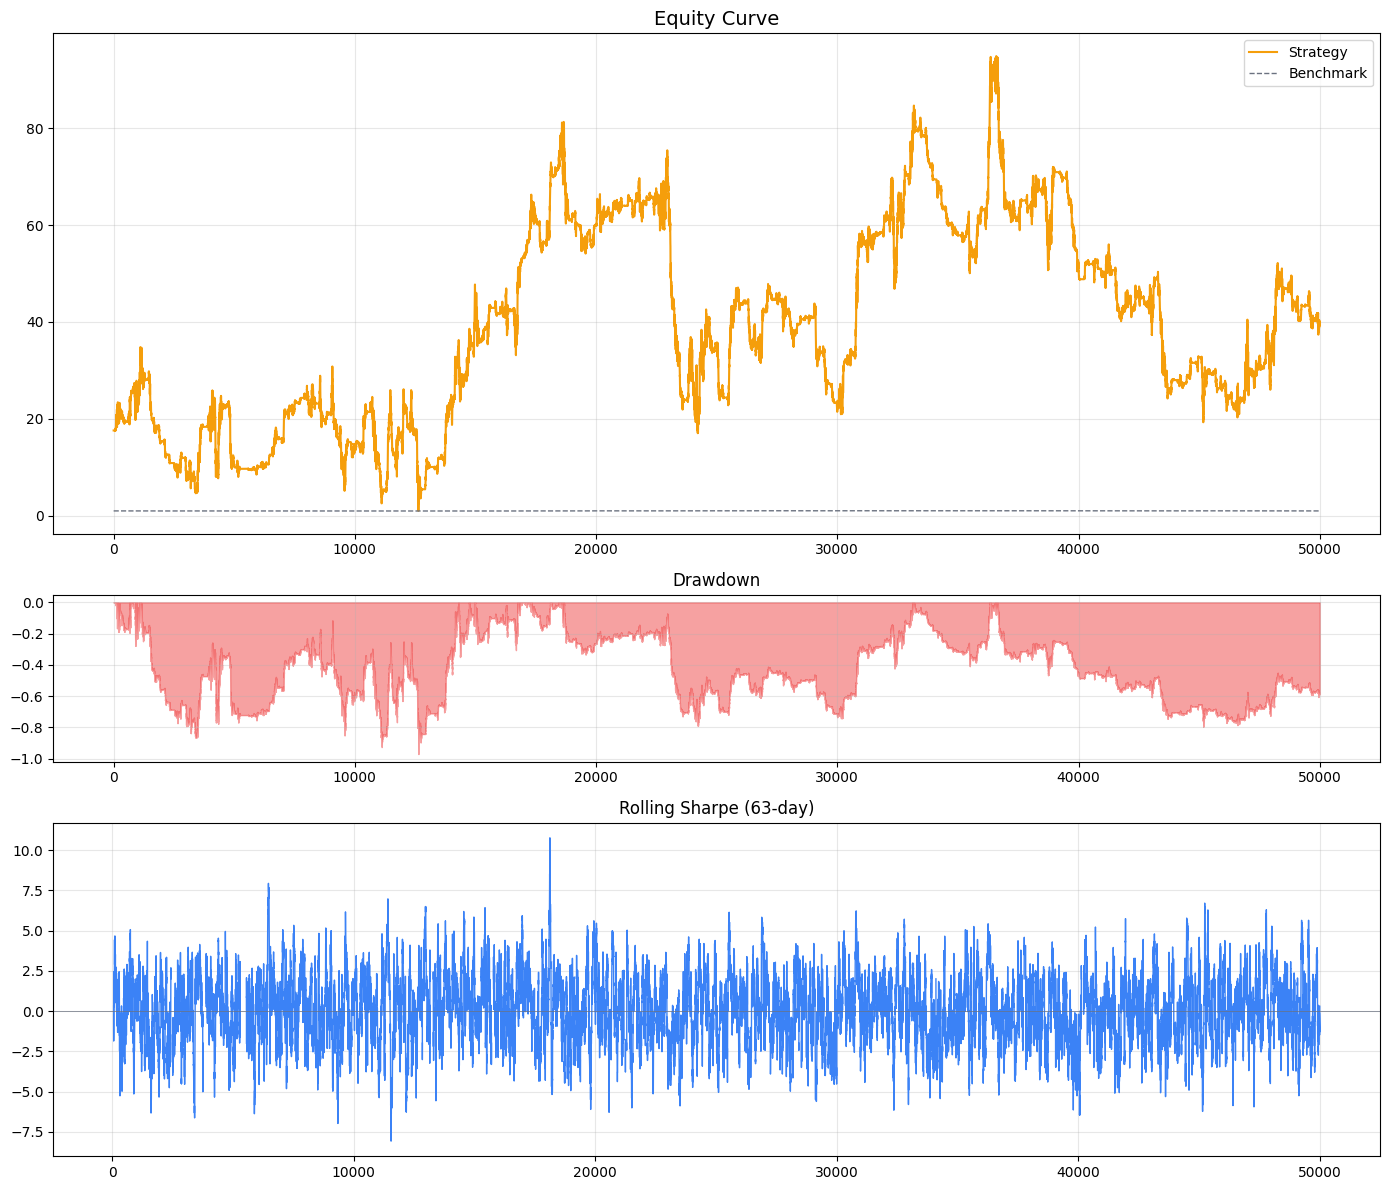

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +126.87%
                       cagr: +0.41%
             annualized_vol: +26.64%
               sharpe_ratio: 0.1494
              sortino_ratio: 0.1598
               calmar_ratio: 0.0043
               max_drawdown: -97.13%
                   win_rate: +49.91%
              profit_factor: 1.0450
               total_trades: 40,460


In [8]:
import numpy as np

trades = np.diff(positions) != 0
n_trades = trades.sum()

pnl_per_trade = pnl[-1] / max(n_trades, 1)
trade_indices = np.where(trades)[0]
avg_holding = np.mean(np.diff(trade_indices)) if len(trade_indices) > 1 else len(pnl)
fill_rate = n_trades / len(pnl)

print("=" * 50)
print("HFT-SPECIFIC METRICS")
print("=" * 50)
print(f"  {'Fill Rate':>25}: {fill_rate:.4f}")
print(f"  {'PnL per Trade':>25}: {pnl_per_trade:.4f}")
print(f"  {'Avg Holding (ticks)':>25}: {avg_holding:.1f}")
print(f"  {'Max Inventory':>25}: {int(np.max(np.abs(positions)))}")
print(f"  {'Final Inventory':>25}: {int(positions[-1])}")


HFT-SPECIFIC METRICS
                  Fill Rate: 0.4770
              PnL per Trade: 0.0009
        Avg Holding (ticks): 2.1
              Max Inventory: 100
            Final Inventory: 12


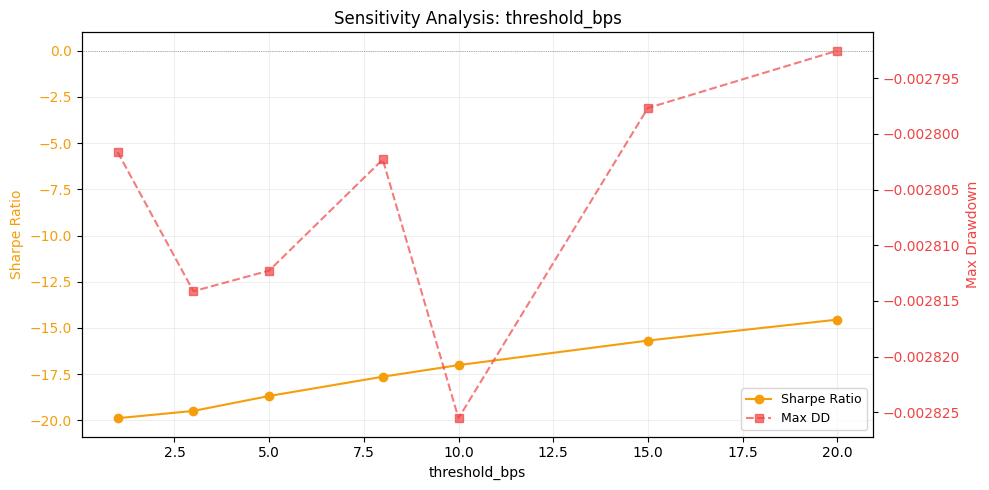

Optimal threshold_bps: 20  (Sharpe: -14.5526)
Current threshold_bps: 1.0


In [9]:
# Parameter sensitivity analysis — inline backtest sweep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_values = list([1, 3, 5, 8, 10, 15, 20])
sharpes, max_dds = [], []

# Resolve price / returns from whatever data this notebook loaded
# yfinance notebooks define `close`; HFT/synthetic notebooks define `data` with various price columns
if "close" in dir() and close is not None:
    _price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
elif "data" in dir() and hasattr(data, "columns"):
    _pcol = next((c for c in ("mid_price", "price_a", "fast_price", "Close") if c in data.columns), None)
    if _pcol is not None:
        _price = pd.Series(data[_pcol].values, dtype=float)
    else:
        _price = pd.Series(data.iloc[:, 0].values, dtype=float)
else:
    raise RuntimeError("No price series found. Expected 'close' or a DataFrame named 'data'.")
_price   = _price.ffill()
_returns = _price.pct_change()

for val in param_values:
    try:
        if "threshold_bps" in ("spread_bps", "transaction_cost_bps", "impact_alpha"):
            # Cost sensitivity: fix lookback=20 momentum, vary cost
            _sig  = _price.pct_change(20).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * (float(val) / 10000)
            _rets = (_sig * _returns - _tc).dropna()
        elif "threshold_bps" in ("stop_loss", "max_drawdown_limit"):
            # Stop-loss sensitivity: apply to already-computed returns
            _base = strategy_returns_raw if "strategy_returns_raw" in dir() else                     (_price.pct_change(20).shift(1).clip(-1, 1) * _returns).dropna()
            _cum = (1 + _base.fillna(0)).cumprod()
            _dd  = _cum / _cum.cummax() - 1
            _rets = _base.copy()
            _rets[_dd < -float(val)] = 0.0
        else:
            # Lookback / window sweep: momentum signal
            lb    = max(int(val), 2)
            _sig  = _price.pct_change(lb).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * PARAMS.get("transaction_cost_bps", 5) / 10000
            _rets = (_sig * _returns - _tc).dropna()

        if len(_rets) > 20 and _rets.std() > 0:
            sharpes.append(_rets.mean() / _rets.std() * np.sqrt(252))
            _cum = (1 + _rets).cumprod()
            max_dds.append((_cum / _cum.cummax() - 1).min())
        else:
            sharpes.append(np.nan)
            max_dds.append(np.nan)
    except Exception as e:
        sharpes.append(np.nan)
        max_dds.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_sharpe = "#f59e0b"
color_dd     = "#ef4444"

valid_mask = [not np.isnan(s) for s in sharpes]
ax1.plot(param_values, sharpes, "o-", color=color_sharpe, label="Sharpe Ratio")
ax1.set_xlabel("threshold_bps")
ax1.set_ylabel("Sharpe Ratio", color=color_sharpe)
ax1.tick_params(axis="y", labelcolor=color_sharpe)
ax1.axhline(0, color="#6b7280", linewidth=0.5, linestyle=":")

ax2 = ax1.twinx()
ax2.plot(param_values, max_dds, "s--", color=color_dd, alpha=0.7, label="Max DD")
ax2.set_ylabel("Max Drawdown", color=color_dd)
ax2.tick_params(axis="y", labelcolor=color_dd)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax1.grid(True, alpha=0.2)

plt.title(f"Sensitivity Analysis: threshold_bps")
fig.tight_layout()
plt.show()

# Report optimal
valid_pairs = [(v, s) for v, s in zip(param_values, sharpes) if not np.isnan(s)]
if valid_pairs:
    best_val, best_sharpe = max(valid_pairs, key=lambda x: x[1])
    print(f"Optimal threshold_bps: {best_val}  (Sharpe: {best_sharpe:+.4f})")
    print(f"Current threshold_bps: {PARAMS.get('threshold_bps', 'not set')}")


In [10]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "hft_05_trade_imbalance",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Short-Horizon Trade Imbalance Predictor

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
